In [1]:
%cd nanoVLM 

import torch
import numpy as np

from models.vl_reasoning_action_model import VLReasoningActionModel
import models.config as config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vlm_cfg = config.VLMConfig()
vlm_cfg.max_img_size = 512

model = VLReasoningActionModel.from_pretrained(
    "/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/checkpoints_emptyenv_action/base_sft/step_0"
)

model = VLReasoningActionModel(
    vlm_cfg,
    load_backbone=True
)

model.to(device)
model.eval()

print("Model loaded.")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/teamspace/studios/this_studio/nanoVLM-action/nanoVLM
Loading from backbone weights
Successfully loaded google/siglip2-base-patch16-512 weights from safetensors. Model has 86,433,024 parameters.
Extending token embeddings from torch.Size([49152, 960]) to torch.Size([49218, 960])
Initialized 66 new token embeddings
Successfully loaded HuggingFaceTB/SmolLM2-360M-Instruct weights from safetensors. Model has 361,884,480 parameters.
Model loaded.


In [10]:
ID2ACTION = {0: "left", 1: "right", 2: "forward"}

from data.emptyenv_action_dataset import EmptyEnvActionDataset, DEFAULT_PROMPT, REASONING_PROMPT

vlm_cfg.max_img_size = 512
full_ds = EmptyEnvActionDataset(
    jsonl_path='/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/data/emptyenv_sft_dataset/test_unseen_sizes/dataset.jsonl',
    images_root='/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/data/emptyenv_sft_dataset/test_unseen_sizes',
    vlm_cfg=vlm_cfg,
    prompt=REASONING_PROMPT,
    max_samples = 20_000
) 


def run_example(idx):
    sample = full_ds[idx]

    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
    images = sample["images"]

    true_label = sample["action_label"]

    with torch.no_grad():
        logits, _, extra = model(
            input_ids=input_ids,
            images=images,
            attention_mask=attention_mask,
            action_labels=None,
            do_reasoning=True,
            reasoning_top_p = 0.75,
            reasoning_top_k = 20,
            max_reasoning_tokens=32,
            reasoning_temperature=0.5,
            reasoning_repetition_penalty=1.2,
            reasoning_greedy=False,
            verbose_reasoning=True
        )

    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred = int(np.argmax(probs))

    print("TRUE:", ID2ACTION[int(true_label)])
    print("PRED:", ID2ACTION[pred])
    print("PROBS:", np.round(probs, 3))

    if "reasoning_text" in extra:
        print("\nREASONING:")
        print(extra["reasoning_text"][0])

import matplotlib.pyplot as plt
import math

def show_env(sample):
    imgs = sample["images"][0]

    n = len(imgs)
    cols = 5
    rows = math.ceil(n / cols)

    plt.figure(figsize=(3*cols, 3*rows))

    for i in range(n):
        plt.subplot(rows, cols, i+1)
        img_np = imgs[i].permute(1,2,0).cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-6)
        plt.imshow(img_np)
        plt.axis("off")

    plt.show()

Resize to max side len: True


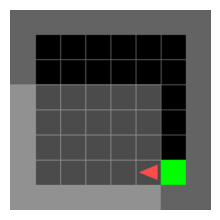

TRUE: left
PRED: forward
PROBS: [0.267 0.238 0.495]

REASONING:
assistant
The green square is located in the same grid world as the agent, and can see it.



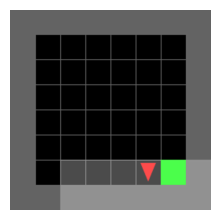

TRUE: left
PRED: forward
PROBS: [0.279 0.253 0.467]

REASONING:
assistant
The green square is in the agent's line of sight, and it can be seen by the agent.



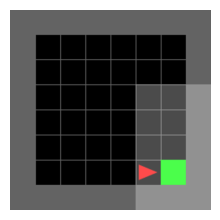

TRUE: forward
PRED: forward
PROBS: [0.286 0.246 0.468]

REASONING:
assistant
The green square is in the top-left corner of a grid world. The agent can see it but not its location relative to itself or



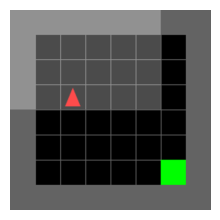

TRUE: right
PRED: forward
PROBS: [0.286 0.239 0.474]

REASONING:
assistant
The green square is at the top-left corner of a grid world, and the agent can see it.



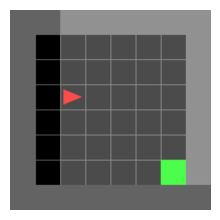

TRUE: forward
PRED: forward
PROBS: [0.288 0.271 0.44 ]

REASONING:
assistant
The green square is on the left side of the grid, and it can see both agents.



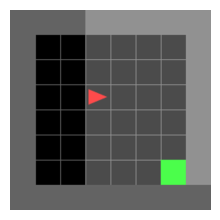

TRUE: forward
PRED: forward
PROBS: [0.303 0.257 0.44 ]

REASONING:
assistant
The green square is in the middle of a grid world, and it can see only one other agent.



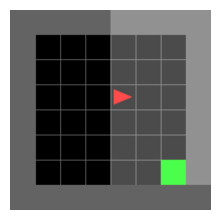

TRUE: forward
PRED: forward
PROBS: [0.281 0.256 0.464]

REASONING:
assistant
The green square is in the 10th row and 5th column relative to the agent, and can see it.


In [11]:
for i in range(7):
    print("\n============================")

    show_env(full_ds[i])
    run_example(i) 